In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd

df = pd.read_csv('/content/placement_predict_50k.csv')

print(df.shape)
df.head()

(50000, 31)


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Certifications,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly
0,1,Female,Delhi,Tier3,IT,DataScience,Yes,Yes,6.39,6.84,...,1,0,62.3,6.57,40.6,65.7,No,Medium,0,0
1,2,Male,Chennai,Tier2,ECE,AI,Yes,No,5.95,6.74,...,2,0,44.0,5.86,40.3,51.8,No,Medium,0,0
2,3,Female,Hyderabad,Tier3,ECE,Networking,No,No,7.13,8.11,...,2,1,73.8,7.50,73.6,67.9,No,High,1,0
3,4,Female,Jaipur,Tier3,ECE,Embedded,No,No,9.37,9.97,...,6,2,100.0,9.41,98.7,NaN,No,Excellent,1,0
4,5,Male,Ahmedabad,Tier3,Mechanical,DataScience,No,No,8.25,8.99,...,4,2,90.8,9.24,83.1,100.0,No,Excellent,1,0


In [7]:
df = df.drop(columns=['IsAnomaly'], errors='ignore')

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print(df.shape)

(50000, 30)


In [8]:
categorical_columns = [
    'Gender',
    'City',
    'CollegeTier',
    'Stream',
    'Specialisation',
    'Hostel',
    'HistoryOfBacklogs',
    'ExtraCurricular'
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 43)
y shape: (50000,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 43)
Testing data: (10000, 43)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(40000, 43) (10000, 43)


In [13]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
gini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

gini.fit(X_train, y_train)
entropy.fit(X_train, y_train)

print("Gini:", accuracy_score(y_test, gini.predict(X_test)))
print("Entropy:", accuracy_score(y_test, entropy.predict(X_test)))

Gini: 0.7946
Entropy: 0.7954


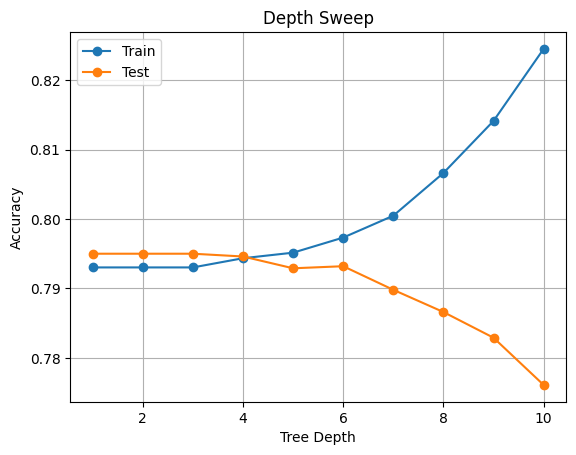

In [16]:
depths = range(1, 11)
train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, train_acc, marker='o', label='Train')
plt.plot(depths, test_acc, marker='o', label='Test')
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Depth Sweep")
plt.legend()
plt.grid()
plt.show()

In [17]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

path = tree.cost_complexity_pruning_path(X_train, y_train)

print(path.ccp_alphas)

[0.00000000e+00 1.24732334e-05 1.65631470e-05 ... 1.51456658e-02
 2.04274388e-02 1.70516115e-01]


In [19]:
scores = []

alphas = np.linspace(
    path.ccp_alphas.min(),
    path.ccp_alphas.max(),
    20
)

for a in alphas:
    model = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    model.fit(X_train, y_train)
    scores.append(accuracy_score(y_test, model.predict(X_test)))

best_alpha = alphas[np.argmax(scores)]

print("Best CCP Alpha:", best_alpha)
print("Best Accuracy:", max(scores))

Best CCP Alpha: 0.008974532345947066
Best Accuracy: 0.795


In [20]:
pruned = DecisionTreeClassifier(
    ccp_alpha=best_alpha,
    random_state=42
)

pruned.fit(X_train, y_train)

print("Pruned Accuracy:",
      accuracy_score(y_test, pruned.predict(X_test)))

Pruned Accuracy: 0.795


In [21]:
best_depth = depths[np.argmax(test_acc)]
print("Best Depth:", best_depth)

Best Depth: 1
